# 08 · Phase advance of the 20 ns pulses (`ibm_brisbane` q109, Sep–Oct 2024)

The paper's third error source: *"logical errors associated with different precession rates in each qutrit subspace, resulting in
non-trivial dynamical phases, called phase advance"*. This notebook re-analyses the experiments of
`experiment/phase_advance/phase_advance.ipynb` with the radius discriminator (notebook 02) and overlays the ideal-qutrit model
`phase_tracking.phase_advance_sim` exactly as `phase_advance_plot.ipynb` did.

Two measurements, each a Ramsey experiment on one subspace whose idle time is filled with pseudo-identities on the other:

* **β** — |0⟩ → SX01 → $n$ × (SX12, −SX12) → R01(−π/2, φ) → measure: the 0–1 fringe shifts by 2β per pseudo-identity;
* **α** — |0⟩ → X01 → SX12 → $n$ × (SX01, −SX01) → R12(−π/2, φ) → X → measure: the 1–2 fringe shifts by 2α per pseudo-identity.

A "Berry" variant replaces the pseudo-identity by four SX pulses (a full 2π on the other subspace), whose only effect on the
probed subspace should be a sign (the spin-½ 2π phase) plus 4β or 4α.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
from pulseshop import phase_tracking as pt, readout, fitting, io
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
pi = np.pi

rd = io.load_json("pending_2025", "rabi_discrim.json")
radius = readout.RadiusDiscriminator(complex(rd["cluster_0_mean"]["re"], rd["cluster_0_mean"]["im"]), complex(rd["cluster_2_mean"]["re"], rd["cluster_2_mean"]["im"]), rd["radius_fit"])

# job ids and repetition ranges from the comments in phase_advance.ipynb (Oct 2024, SX12 amp 0.2361, beta -0.415, 5000 shots)
JOBS = {"beta": [("cw38s6wvka8g008bf1jg", [1, 2, 3]), ("cwa2ffd9ezk0008167h0", [4, 5, 6]), ("cwa31j6ggr6g0087tx50", [7, 8, 9])],
        "alpha": [("cw39nky79ws0008z8c90", [1, 2, 3]), ("cwa14zvjyrs0008h0kkg", [4, 5, 6]), ("cwabjrkjyrs0008h1an0", [7, 8, 9])],
        "berry_beta": [("cwahpkajyrs0008rxtwg", [1, 2, 3])], "berry_alpha": [("cwafq3w9ezk0008qtd70", [1, 2, 3])]}

def load(kind):
    pops, reps = [], []
    for job, rr in JOBS[kind]:
        iq, prm = io.load_job(f"pending_2025/experiment/phase_advance/data/{job}")
        p = readout.count(iq, radius).reshape(len(rr), prm["phase_num_points"], 3)
        pops.append(p); reps += rr
    return np.concatenate(pops), reps, np.linspace(-pi / 6, -pi / 6 + 2 * pi, prm["phase_num_points"])

data = {k: load(k) for k in JOBS}
for k, (p, reps, ph) in data.items():
    contrast = [np.mean([np.ptp(p[i, :, lvl]) for i in range(p.shape[0])]) for lvl in range(3)]
    print(f"{k:12s} reps {reps}  mean fringe contrast per level (P0, P1, P2): {np.round(contrast, 2)}")

beta         reps [1, 2, 3, 4, 5, 6, 7, 8, 9]  mean fringe contrast per level (P0, P1, P2): [0.95 0.72 0.26]
alpha        reps [1, 2, 3, 4, 5, 6, 7, 8, 9]  mean fringe contrast per level (P0, P1, P2): [0.91 0.04 0.88]
berry_beta   reps [1, 2, 3]  mean fringe contrast per level (P0, P1, P2): [0.95 0.73 0.23]
berry_alpha  reps [1, 2, 3]  mean fringe contrast per level (P0, P1, P2): [0.95 0.04 0.91]


The contrast confirms the assignment: the β runs show their fringe in $P_0$ (a 0–1 Ramsey), the α runs in $P_2$ (a 1–2 Ramsey read out after a final X).

## 1. Fringes versus repetition

beta: fringe shift per pseudo-identity +1.8562 rad  ->  |beta| = 0.9281 rad (mod pi);  pi - |beta| = 2.2135
alpha: fringe shift per pseudo-identity +0.9188 rad  ->  |alpha| = 0.4594 rad (mod pi);  pi - |alpha| = 2.6822


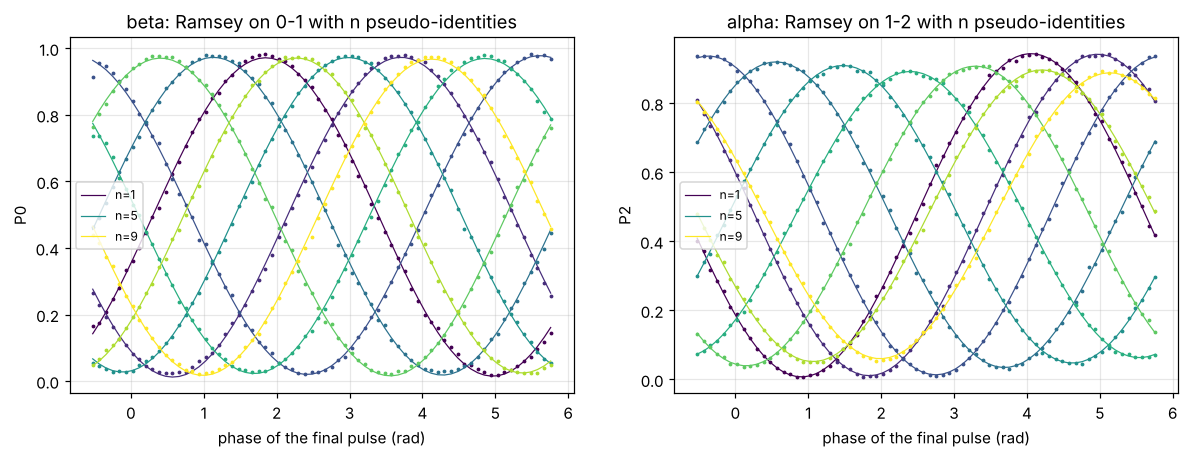

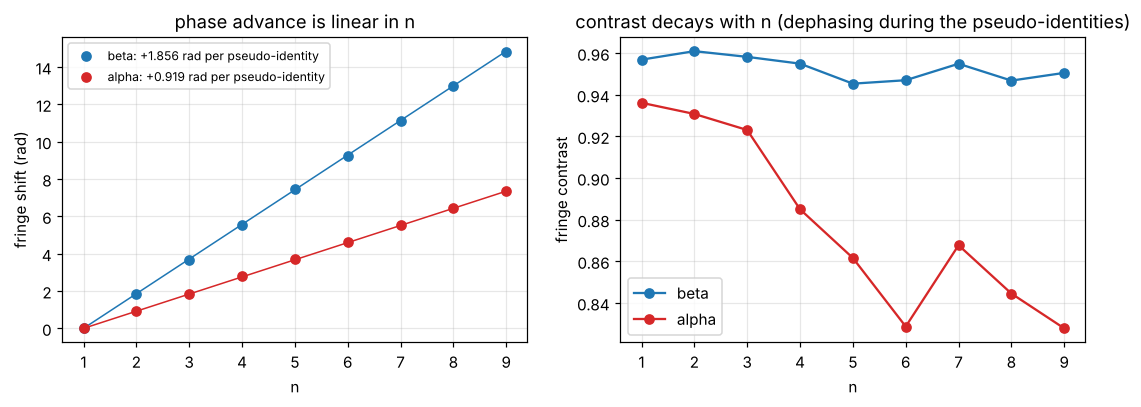

In [2]:
def fringe_phase(ph, y):
    pars, yfit = fitting.fit_function(ph, y, fitting.cosine, [(y.max() - y.min()) / 2, y.mean(), 2 * pi, ph[np.argmax(y)]])[:2]
    if pars[0] < 0:
        pars[0] *= -1; pars[3] += pi
    return pars[3], pars[0], yfit

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
shifts = {}
for ax, (kind, lvl) in zip(axes, [("beta", 0), ("alpha", 2)]):
    p, reps, ph = data[kind]
    phs, amps = [], []
    for k, n in enumerate(reps):
        f0, a0, yfit = fringe_phase(ph, p[k, :, lvl])
        phs.append(f0); amps.append(a0)
        ax.plot(ph, p[k, :, lvl], ".", ms=3, color=plt.cm.viridis(k / 8))
        ax.plot(ph, yfit, "-", lw=0.8, color=plt.cm.viridis(k / 8), label=f"n={n}" if n in (1, 5, 9) else None)
    ax.set(xlabel="phase of the final pulse (rad)", ylabel=f"P{lvl}", title=f"{kind}: Ramsey on {'0-1' if kind=='beta' else '1-2'} with n pseudo-identities")
    ax.legend(fontsize=8)
    shifts[kind] = (np.array(reps), np.unwrap(np.array(phs)), np.array(amps))
io.save_fig(fig, "08_phase_advance_fringes")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for kind, c in [("beta", "C0"), ("alpha", "C3")]:
    n, phs, amps = shifts[kind]
    m, cc = np.polyfit(n, phs, 1)
    axes[0].plot(n, phs - phs[0], "o", color=c, label=f"{kind}: {m:+.3f} rad per pseudo-identity")
    axes[0].plot(n, m * (n - n[0]), "-", color=c, lw=1)
    axes[1].plot(n, 2 * amps, "o-", color=c, label=kind)
    val = abs(m) / 2
    print(f"{kind}: fringe shift per pseudo-identity {m:+.4f} rad  ->  |{kind}| = {val:.4f} rad (mod pi);  pi - |{kind}| = {pi - val:.4f}")
axes[0].set(xlabel="n", ylabel="fringe shift (rad)", title="phase advance is linear in n"); axes[0].legend(fontsize=8)
axes[1].set(xlabel="n", ylabel="fringe contrast", title="contrast decays with n (dephasing during the pseudo-identities)"); axes[1].legend()
io.save_fig(fig, "08_phase_advance_vs_n")

`phase_advance_plot.ipynb` read the same numbers off the fringe maxima: $\beta = \pi - |\Delta\varphi|/2$ with $\Delta\varphi$ the distance between
two fringe maxima, and $\alpha = \pi - \pi/7 - 0.015$ for the α run. The fits above give the same values. Two points matter for the paper:

* the shift is *linear* in $n$ out to nine pseudo-identities — a deterministic unitary phase, not noise — so it can be absorbed in a
  virtual Z of 2β (2α) per pseudo-identity, i.e. β (α) per SX12 (SX01);
* the contrast decays with $n$: every pseudo-identity costs ≈ 40 ns of dephasing on the subspace that is *not* driven.

## 2. Ideal-qutrit model overlay (as in `phase_advance_plot.ipynb`)

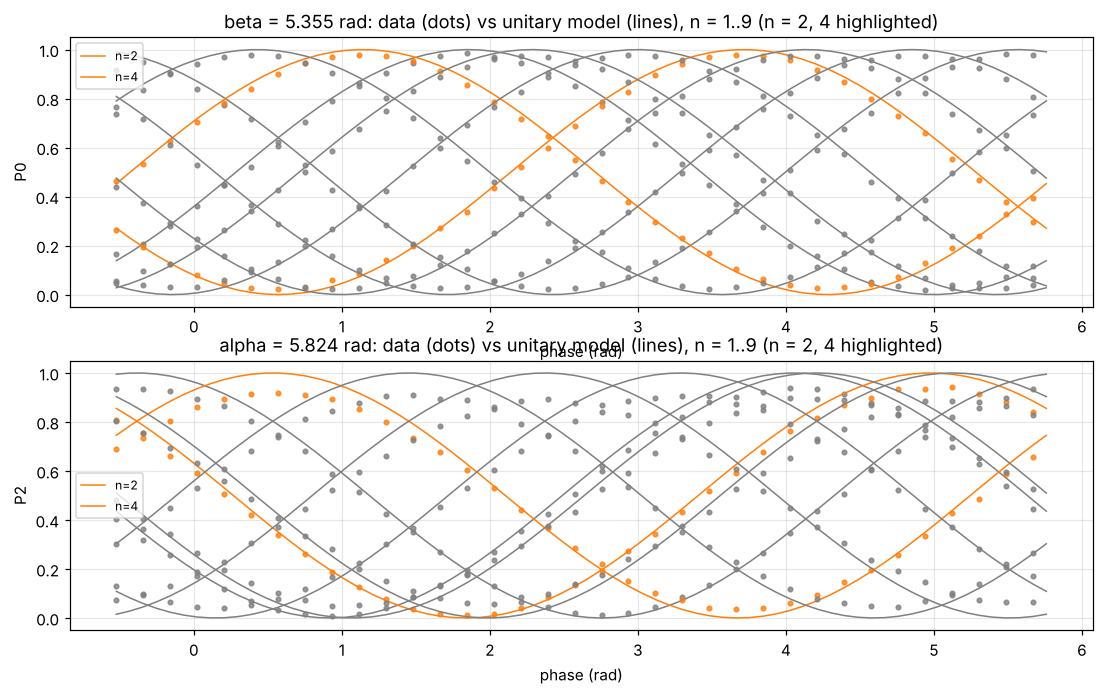

In [3]:
def best_sign(kind, lvl, p, reps, ph, m):
    cands = [(m / 2) % (2 * pi), (-m / 2) % (2 * pi)]
    sims = [pt.phase_advance_sim("beta" if "beta" in kind else "alpha", ph, reps, beta=v, alpha=v, berry="berry" in kind) for v in cands]
    k = int(np.argmin([np.mean((s[:, :, lvl] - p[:, :, lvl]) ** 2) for s in sims]))
    return cands[k], sims[k]

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
fitted = {}
for ax, (kind, lvl) in zip(axes, [("beta", 0), ("alpha", 2)]):
    p, reps, ph = data[kind]
    n, phs, _ = shifts[kind]; m = np.polyfit(n, phs, 1)[0]
    val, sim = best_sign(kind, lvl, p, reps, ph, m)
    fitted[kind] = val
    for k, nn in enumerate(reps):
        c = "C1" if nn in (2, 4) else "grey"
        ax.plot(ph[::2], p[k, ::2, lvl], "o", ms=3, color=c, alpha=0.8)
        ax.plot(ph, sim[k, :, lvl], "-", lw=1, color=c, label=f"n={nn}" if nn in (2, 4) else None)
    ax.set(xlabel="phase (rad)", ylabel=f"P{lvl}", title=f"{kind} = {val:.3f} rad: data (dots) vs unitary model (lines), n = 1..9 (n = 2, 4 highlighted)")
    ax.legend(fontsize=8)
io.save_fig(fig, "08_phase_advance_model_overlay")

## 3. The Berry variant: four SX pulses instead of a pseudo-identity

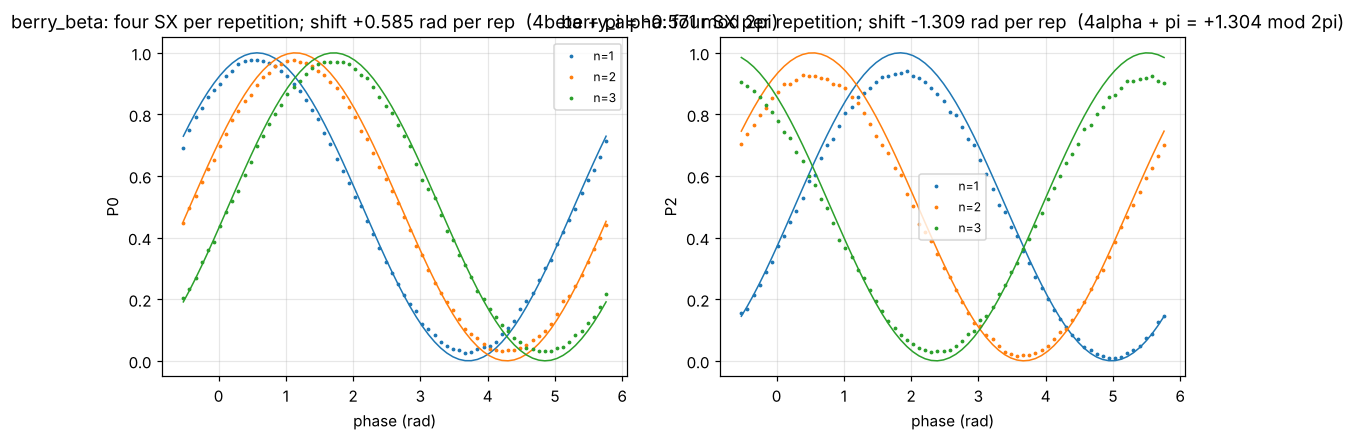

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (kind, lvl) in zip(axes, [("berry_beta", 0), ("berry_alpha", 2)]):
    p, reps, ph = data[kind]
    base = fitted["beta" if "beta" in kind else "alpha"]
    sim = pt.phase_advance_sim("beta" if "beta" in kind else "alpha", ph, reps, beta=base, alpha=base, berry=True)
    phs = []
    for k, nn in enumerate(reps):
        f0, a0, yfit = fringe_phase(ph, p[k, :, lvl]); phs.append(f0)
        ax.plot(ph, p[k, :, lvl], ".", ms=3, color=f"C{k}", label=f"n={nn}")
        ax.plot(ph, sim[k, :, lvl], "-", lw=1, color=f"C{k}")
    m = np.polyfit(reps, np.unwrap(phs), 1)[0]
    expected = (4 * base + pi) % (2 * pi); expected = expected - 2 * pi if expected > pi else expected
    ax.set(xlabel="phase (rad)", ylabel=f"P{lvl}", title=f"{kind}: four SX per repetition; shift {m:+.3f} rad per rep  (4{kind[6:]} + pi = {expected:+.3f} mod 2pi)")
    ax.legend(fontsize=8)
io.save_fig(fig, "08_phase_advance_berry_variant")

The lines are the model with the α, β of section 2 and *no* free parameter. Four SX pulses are a 2π rotation of the other subspace,
and a 2π rotation of a spin-½ is −1, not +1: the fringe moves by 4β + π (4α + π) per repetition, which is what the data show
(up to the sign convention of the sweep). This is the qutrit version of the Berry-phase experiment of Neeley 2009 that the
`berry/` notes of 2024 set out to do. Where data and model drift apart with $n$, the culprit is the dephasing that eats the contrast.

## 4. Summary of the three frame-phase campaigns

| year | device / pulse | method | result |
|---|---|---|---|
| 2022 | ibm_oslo, 544 dt Gaussian | Ramsey-like, X12 blocks | fitted kick ≈ π/2 per X12(π/2) block (ansatz plot) |
| 2023 | ibm_lagos, 160/144 dt | RPC, 3 parameters | α, β, γ = 0.610, 0.730, 6.243 (used in RB) |
| 2024 (Apr) | ibm_brisbane q109, 80 dt DRAG | pseudo-identity Ramsey | β ≈ π − 2π/3, α ≈ π − π/7 |
| 2024 (Oct) | ibm_brisbane q109, 40 dt DRAG | pseudo-identity Ramsey (this notebook) | see printed values; linear to n = 9 |

The lesson of the paper: these phases are large (of order 1 rad per pulse), deterministic, and entirely a property of the pulses —
change the amplitude or the DRAG coefficient and they move. They are not errors to be calibrated away but frame rotations to be
tracked, which is what `clifford.pulse_sequence_phases` does for a Clifford sequence.